In [ ]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances, silhouette_score
from scipy.spatial import ConvexHull
import glob
import os
from tqdm import tqdm

In [ ]:
# --- 1. CONFIGURATION ---
DATA_PATH = '/content'
OUTPUT_JSON = "final_curated_dataset.json"
REPORT_METADATA = "curation_report_metadata.csv"


In [ ]:
RANDOM_STATE = 42
SAMPLES_PER_CLUSTER = 4  # We pick 4: Centroid, Max Outlier, 2 Variants
MIN_K = 3   # Minimum clusters to auto-detect per domain
MAX_K = 10  # Maximum clusters to auto-detect per domain

In [ ]:
# --- 2. HELPER FUNCTIONS ---

def load_data(path):
    files = glob.glob(os.path.join(path, "*.json"))
    data = []
    print(f"Loading {len(files)} files from {path}...")
    for f in tqdm(files):
        try:
            with open(f, 'r') as file:
                content = json.load(file)
                if isinstance(content, list): data.extend(content)
                else: data.append(content)
        except: pass
    return pd.DataFrame(data)

def find_optimal_k_with_inertia(embeddings, domain_name):
    """
    Calculates BOTH Silhouette Score and Inertia (Elbow) for graphing.
    """
    sil_scores = []
    inertias = [] # Store inertia for Elbow Plot
    k_range = range(MIN_K, min(MAX_K + 1, len(embeddings)))

    if len(embeddings) < MIN_K + 1:
        return len(embeddings), [], []

    print(f"  > Auto-tuning K for {domain_name}...")
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        labels = kmeans.fit_predict(embeddings)

        # Metrics
        score = silhouette_score(embeddings, labels)
        sil_scores.append(score)
        inertias.append(kmeans.inertia_) # Capture "Error"

    if not sil_scores: return MIN_K, [], []

    # We still pick Best K based on Silhouette (it's more reliable than Elbow)
    best_idx = np.argmax(sil_scores)
    best_k = k_range[best_idx]
    print(f"  > Optimal K: {best_k} (Silhouette: {sil_scores[best_idx]:.3f})")

    return best_k, sil_scores, inertias

def farthest_point_sampling(embeddings, n_samples, centroid_idx):
    n_points = embeddings.shape[0]
    if n_points <= n_samples:
        return np.arange(n_points), ["Keep All"] * n_points

    selected_indices = [centroid_idx]
    reasons = ["Centroid (Task 1)"]

    for i in range(n_samples - 1):
        dists = pairwise_distances(embeddings, embeddings[selected_indices])
        min_dists = np.min(dists, axis=1)
        next_idx = np.argmax(min_dists)
        selected_indices.append(next_idx)

        if i == 0: reasons.append("Max Outlier (Task 2)")
        else: reasons.append(f"Variant (Diversity)")

    return selected_indices, reasons


In [ ]:
# --- 3. MAIN ORCHESTRATOR ---

def run_pipeline():
    df = load_data(DATA_PATH)
    if df.empty: return

    print("\n--- VECTORIZING ---")
    df['rich_signal'] = df.apply(
        lambda x: f"{x.get('domain', 'General')} call regarding {x.get('intent', 'Unknown')}: {x.get('reason_for_call', '')}",
        axis=1
    )
    model = SentenceTransformer('all-MiniLM-L6-v2')

    selected_global_ids = []
    metadata_log = []
    unique_domains = df['domain'].unique()

    for domain in unique_domains:
        domain_df = df[df['domain'] == domain]
        domain_indices = domain_df.index.to_numpy()

        if len(domain_df) < 10:
            selected_global_ids.extend(domain_indices)
            continue

        print(f"\n--- DOMAIN: {domain} ({len(domain_df)} samples) ---")

        embeddings = model.encode(domain_df['rich_signal'].tolist())

        # 1. Auto-Tune (Get K, Scores, AND Inertia)
        best_k, sil_scores, inertias = find_optimal_k_with_inertia(embeddings, domain)

        # 2. Cluster
        kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
        labels = kmeans.fit_predict(embeddings)
        all_dists = kmeans.transform(embeddings)

        # 3. FPS Selection
        pca = PCA(n_components=2)
        coords_2d = pca.fit_transform(embeddings)
        selected_points_map = {}

        for i in range(best_k):
            cluster_mask = (labels == i)
            cluster_local_idxs = np.where(cluster_mask)[0]
            if len(cluster_local_idxs) == 0: continue

            local_centroid_idx = np.argmin(all_dists[cluster_mask, i])
            cluster_embs = embeddings[cluster_mask]
            fps_indices, reasons = farthest_point_sampling(cluster_embs, SAMPLES_PER_CLUSTER, local_centroid_idx)

            selected_points_map[i] = coords_2d[cluster_local_idxs[fps_indices]]

            for fps_local, reason in zip(fps_indices, reasons):
                global_idx = domain_indices[cluster_local_idxs[fps_local]]
                if global_idx not in selected_global_ids:
                    selected_global_ids.append(global_idx)
                    metadata_log.append({
                        "transcript_id": df.loc[global_idx, 'transcript_id'],
                        "domain": domain,
                        "reason": reason
                    })

        # 4. VISUALIZATION (3 GRAPHS NOW)
        fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 6))
        k_range = range(MIN_K, MIN_K + len(sil_scores))

        # Graph A: Elbow (Inertia)
        ax1.plot(k_range, inertias, 'bo-', markersize=8)
        ax1.set_title(f'{domain}: Elbow Method (Inertia)')
        ax1.set_xlabel('Number of Clusters (k)')
        ax1.set_ylabel('Inertia (Lower is Better)')
        ax1.grid(True, alpha=0.3)

        # Graph B: Silhouette (Quality)
        ax2.plot(k_range, sil_scores, 'go-', markersize=8)
        ax2.axvline(x=best_k, color='r', linestyle='--', label=f'Optimal k={best_k}')
        ax2.set_title(f'{domain}: Silhouette Analysis (Higher is Better)')
        ax2.set_xlabel('Number of Clusters (k)')
        ax2.legend()
        ax2.grid(True, alpha=0.3)

        # Graph C: The Strategy Map
        colors = plt.cm.tab10(np.linspace(0, 1, best_k))
        ax3.scatter(coords_2d[:, 0], coords_2d[:, 1], c=labels, cmap='Pastel1',
                   s=60, alpha=0.6, edgecolors='gray', linewidth=0.5, label='Full Population')

        for i in range(best_k):
            cluster_points = coords_2d[labels == i]
            if len(cluster_points) >= 3:
                hull = ConvexHull(cluster_points)
                for simplex in hull.simplices:
                    ax3.plot(cluster_points[simplex, 0], cluster_points[simplex, 1], color=colors[i], lw=2, alpha=0.8)
                ax3.fill(cluster_points[hull.vertices, 0], cluster_points[hull.vertices, 1], color=colors[i], alpha=0.1)

            if i in selected_points_map:
                sel_pts = selected_points_map[i]
                ax3.scatter(sel_pts[0][0], sel_pts[0][1], color=colors[i], marker='*', s=350, edgecolors='black', zorder=10) # Centroid
                if len(sel_pts) > 1:
                    ax3.scatter(sel_pts[1][0], sel_pts[1][1], color=colors[i], marker='X', s=200, edgecolors='black', zorder=10) # Outlier
                if len(sel_pts) > 2:
                    for pt in sel_pts[2:]:
                        ax3.scatter(pt[0], pt[1], color=colors[i], marker='^', s=120, edgecolors='black', zorder=10) # Variants

        ax3.set_title(f'{domain}: FPS Strategy Map (k={best_k})')
        from matplotlib.lines import Line2D
        legend_elements = [
            Line2D([0], [0], marker='*', color='w', markerfacecolor='black', markersize=15, label='Centroid (Task 1)'),
            Line2D([0], [0], marker='X', color='w', markerfacecolor='black', markersize=10, label='Outlier (Task 2)'),
            Line2D([0], [0], marker='^', color='w', markerfacecolor='black', markersize=10, label='Variant (Diversity)')
        ]
        ax3.legend(handles=legend_elements, loc='upper right')
        ax3.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    # D. EXPORT
    print("\n--- SAVING ---")
    final_json_objects = [df.iloc[i].to_dict() for i in selected_global_ids]
    for obj in final_json_objects:
        if 'rich_signal' in obj: del obj['rich_signal']

    with open(OUTPUT_JSON, 'w') as f:
        json.dump(final_json_objects, f, indent=2)

    meta_df = pd.DataFrame(metadata_log)
    meta_df.to_csv(REPORT_METADATA, index=False)

    print(f"Selected {len(final_json_objects)} transcripts.")
    print(f"Saved to {OUTPUT_JSON} and {REPORT_METADATA}")

Loading 2 files from /content...


100%|██████████| 2/2 [00:03<00:00,  1.62s/it]



--- VECTORIZING ---

--- DOMAIN: Hotel (3365 samples) ---
  > Auto-tuning K for Hotel...
  > Optimal K: 6 (Silhouette: 0.191)


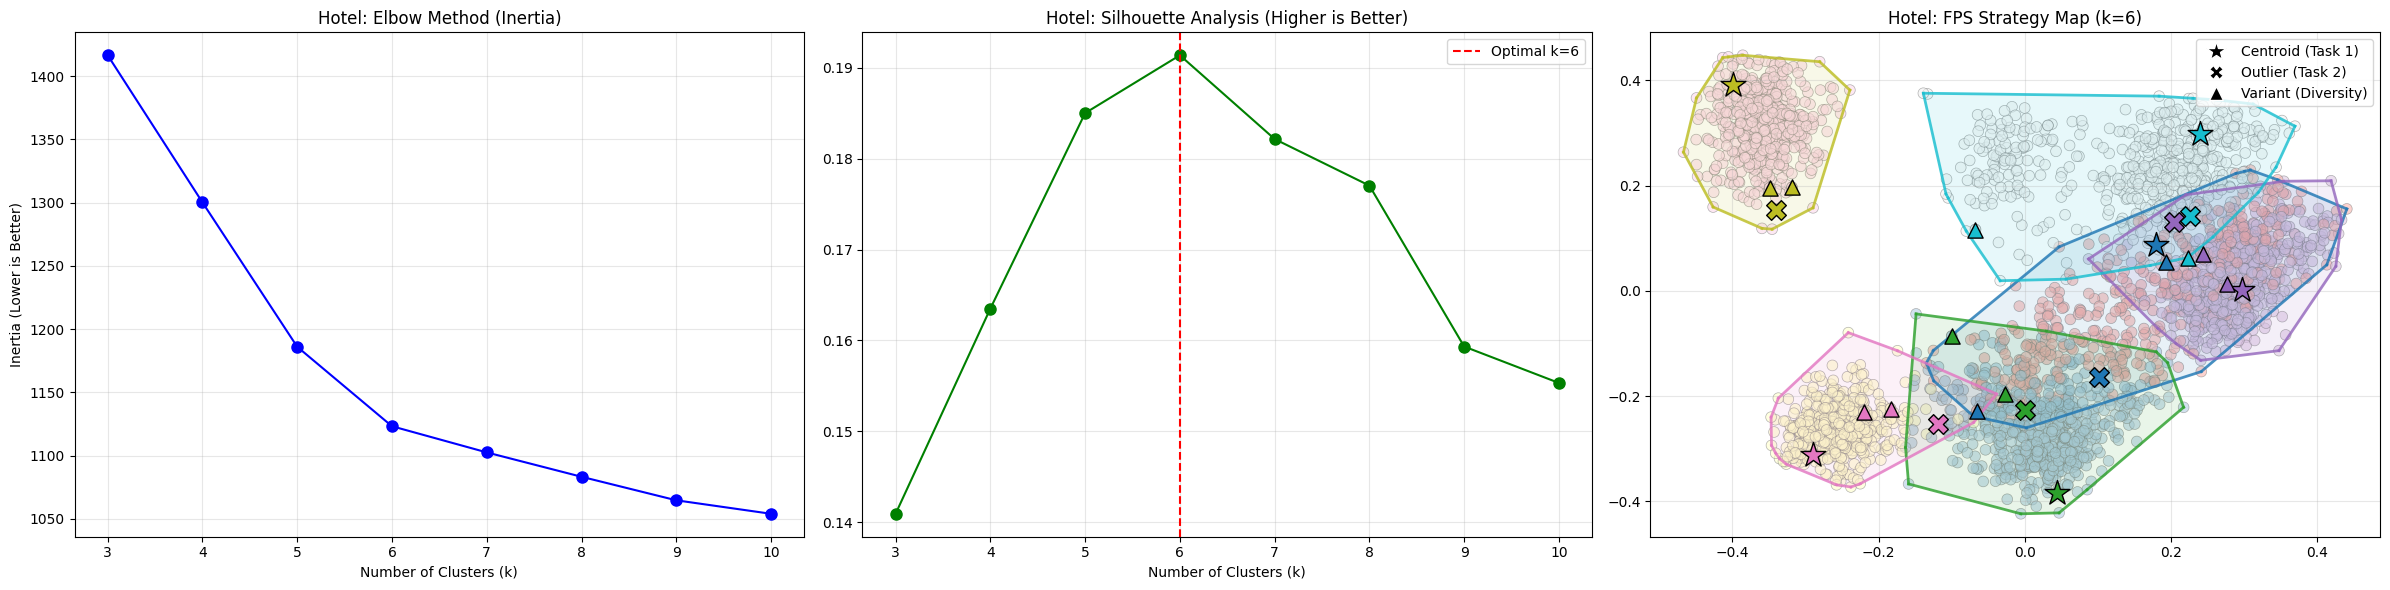


--- DOMAIN: Flight (3444 samples) ---
  > Auto-tuning K for Flight...
  > Optimal K: 4 (Silhouette: 0.197)


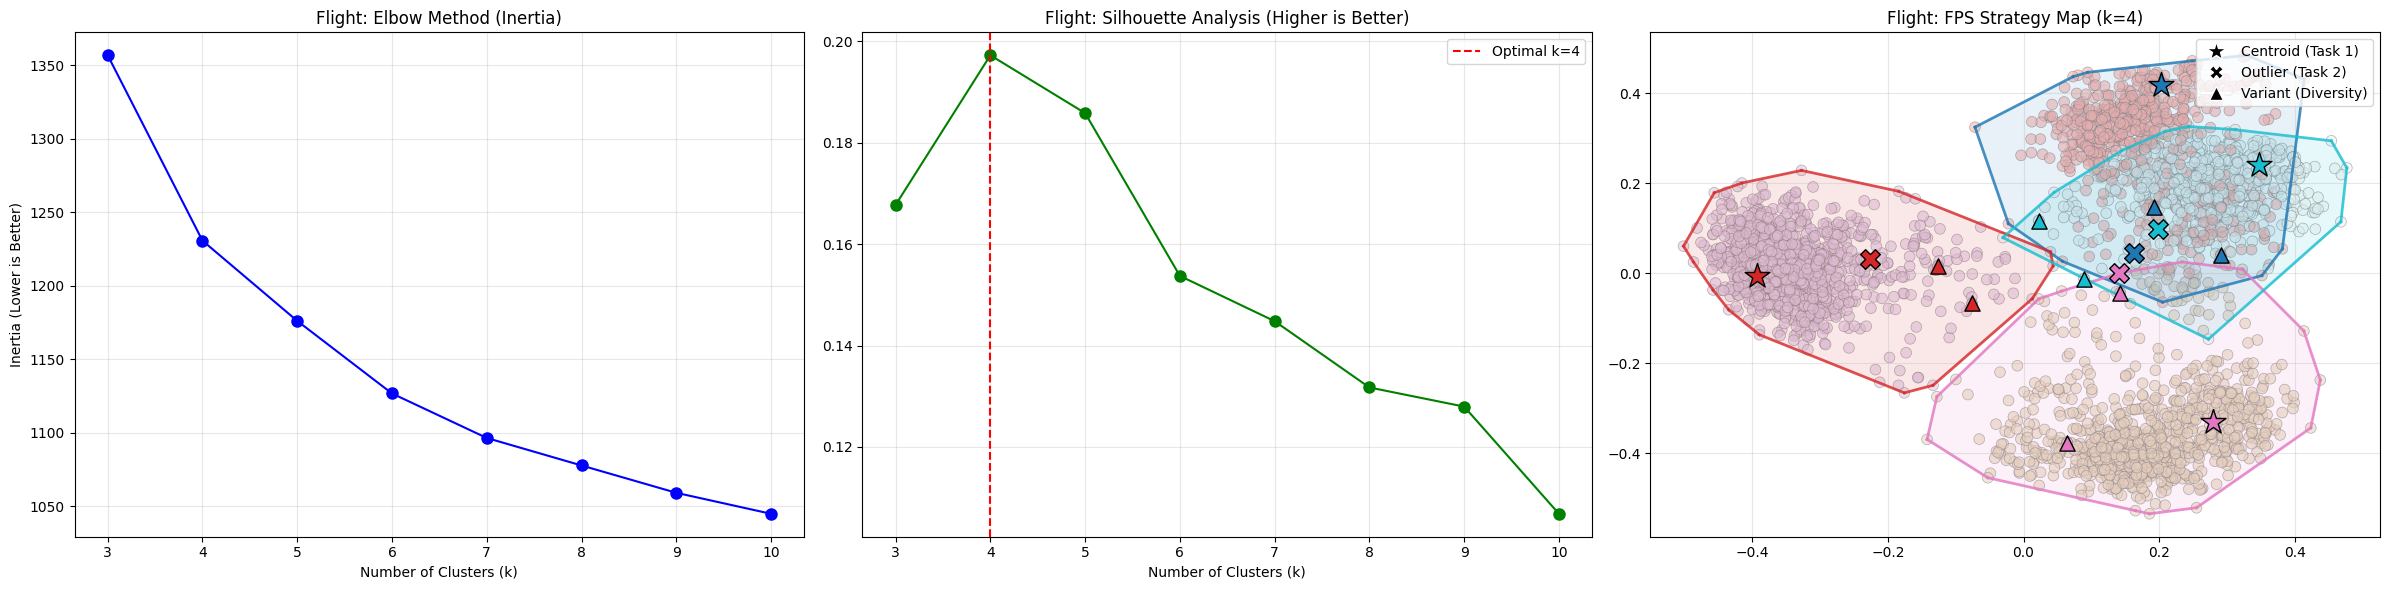


--- DOMAIN: Retail (3134 samples) ---
  > Auto-tuning K for Retail...
  > Optimal K: 4 (Silhouette: 0.203)


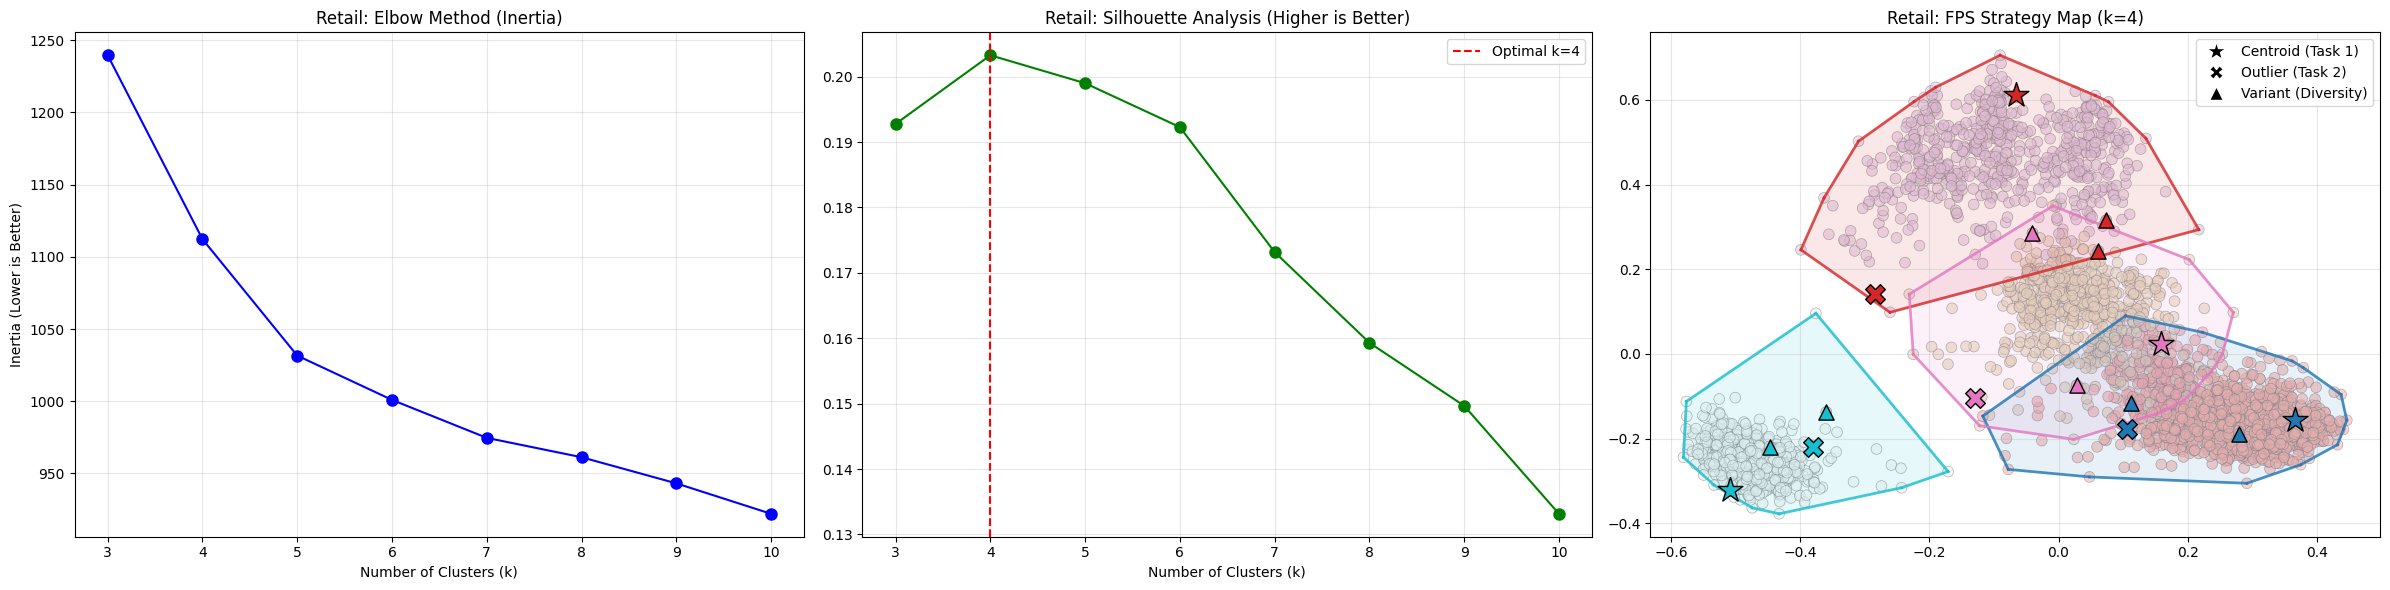


--- DOMAIN: Banking (3067 samples) ---
  > Auto-tuning K for Banking...
  > Optimal K: 6 (Silhouette: 0.234)


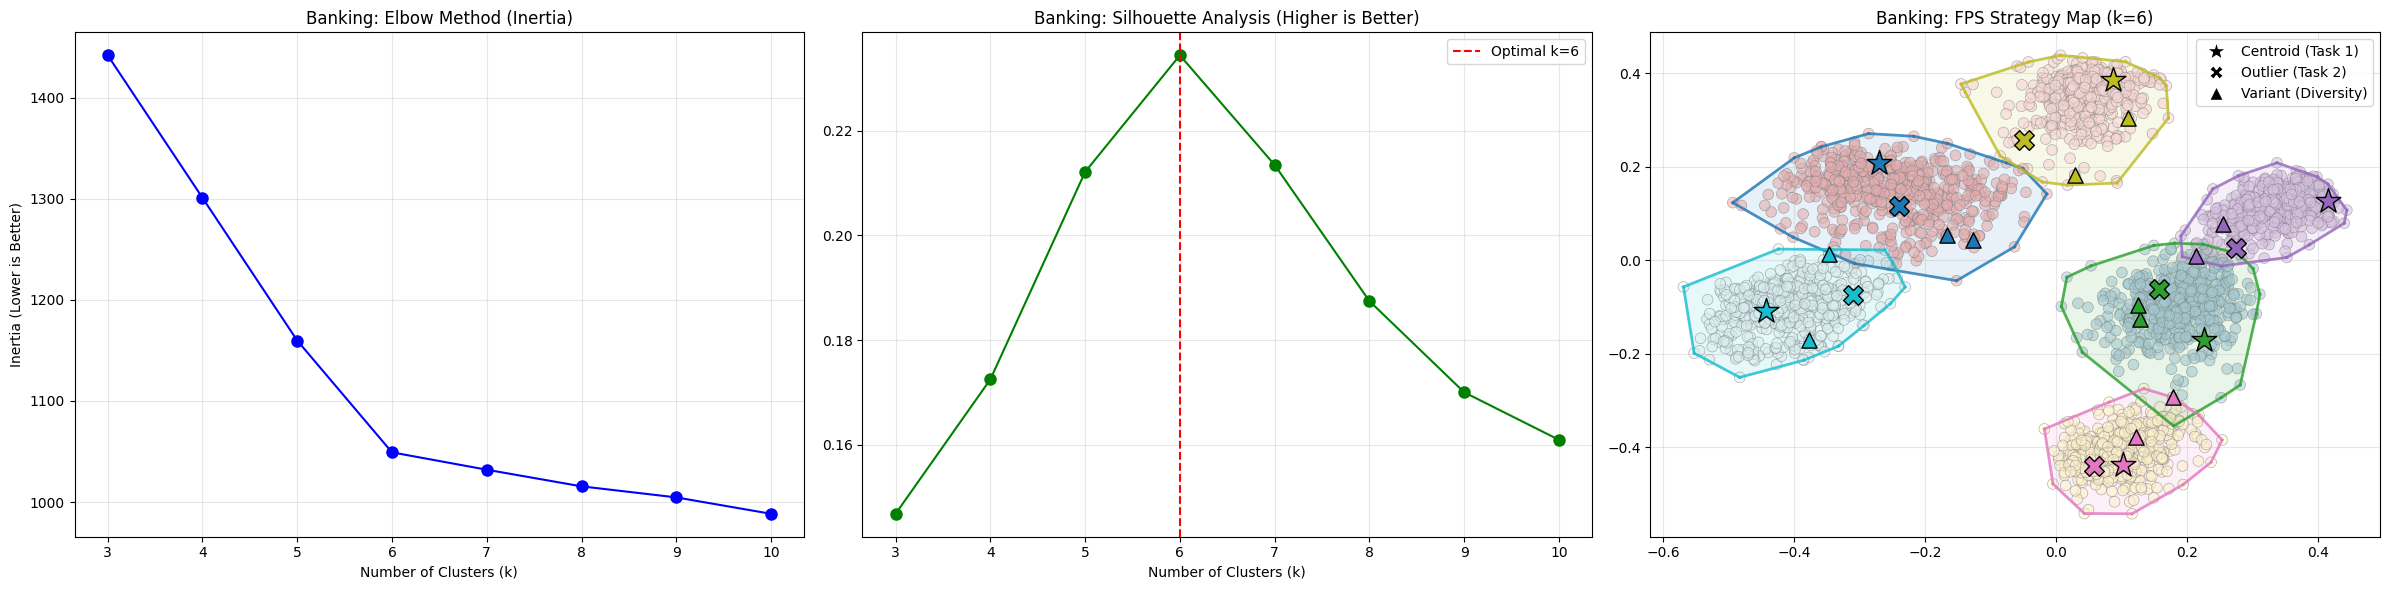


--- DOMAIN: Telecom (3348 samples) ---
  > Auto-tuning K for Telecom...
  > Optimal K: 4 (Silhouette: 0.194)


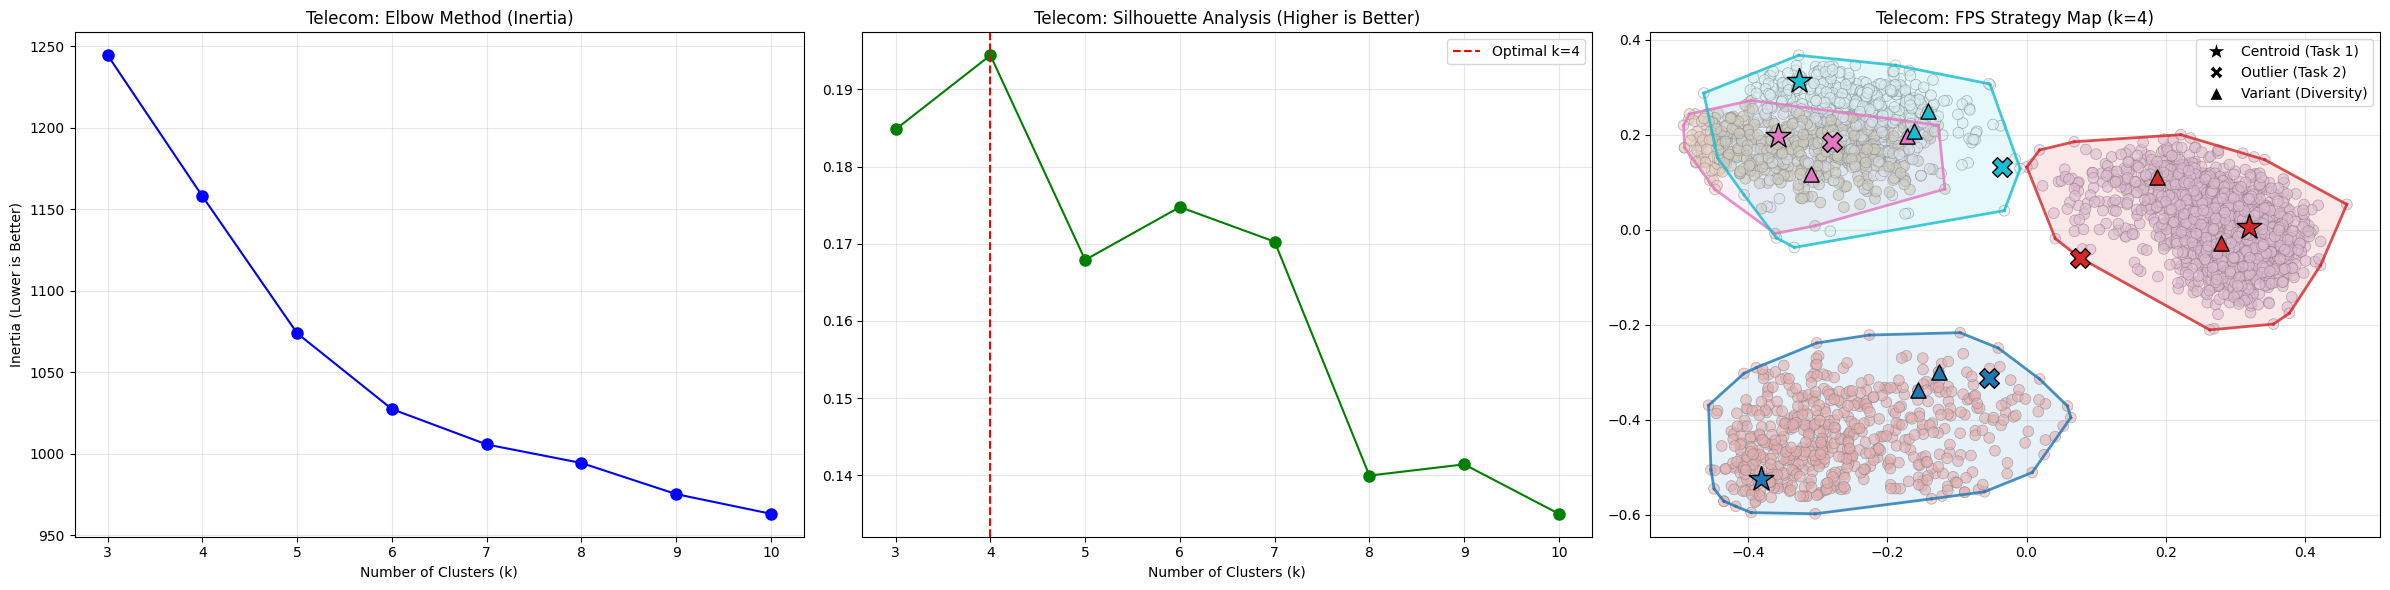


--- DOMAIN: Insurance (3387 samples) ---
  > Auto-tuning K for Insurance...
  > Optimal K: 7 (Silhouette: 0.180)


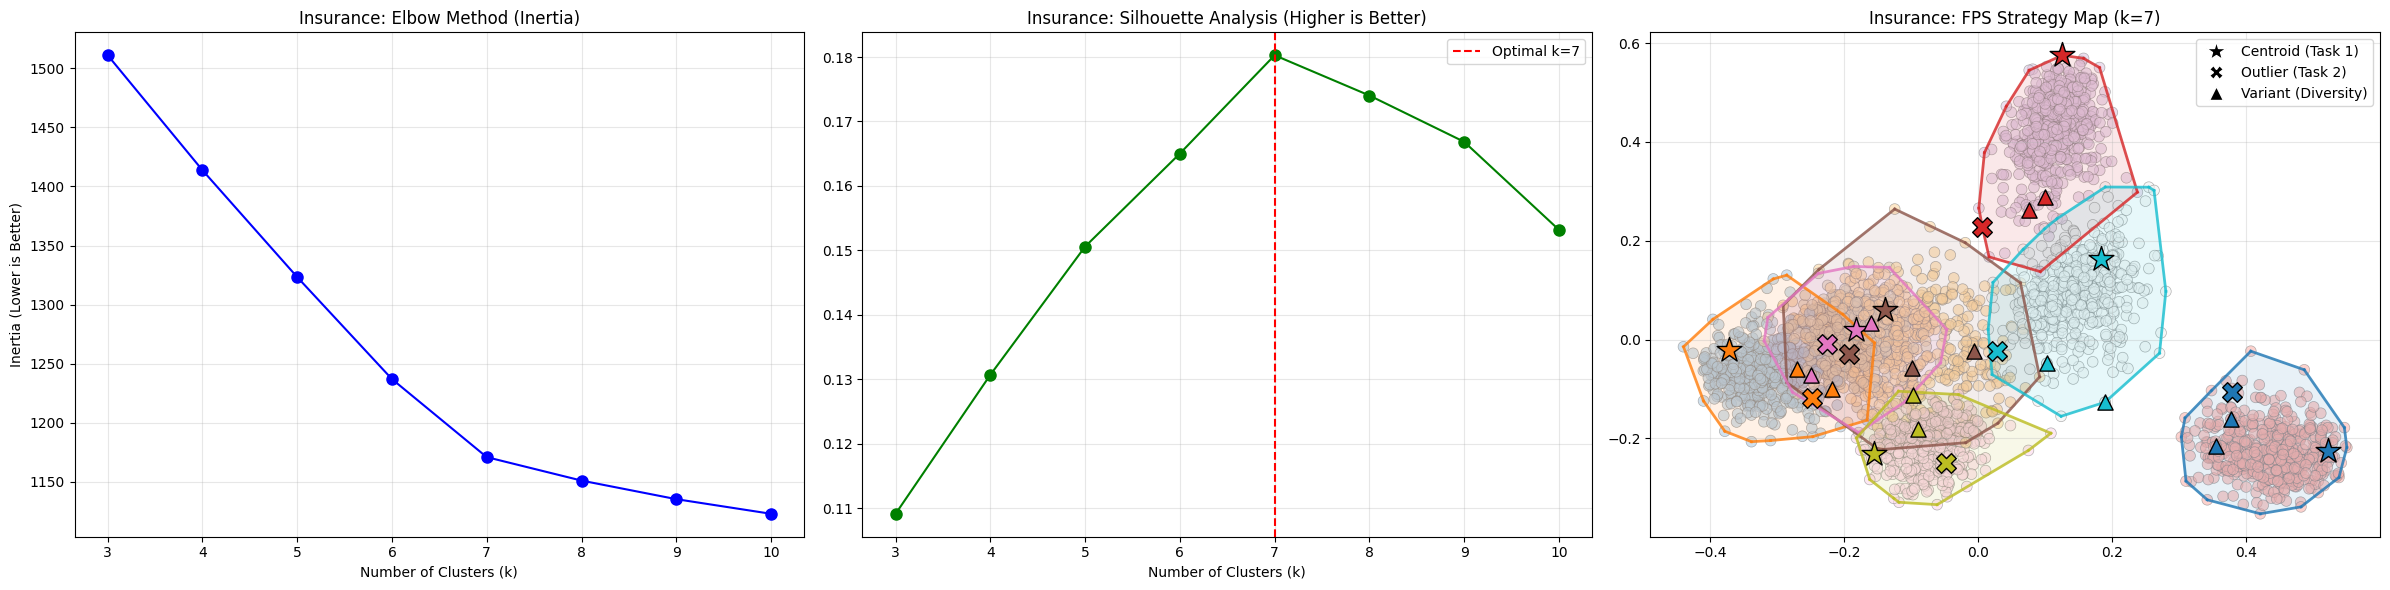


--- SAVING ---
Selected 124 transcripts.
Saved to final_curated_dataset.json and curation_report_metadata.csv


In [ ]:
# --- RUN IT ---
run_pipeline()